In [2]:
# Cell 1 — imports
import shap
import joblib
import pandas as pd
import matplotlib.pyplot as plt

c:\Users\waghs.DESKTOP-OFO3QK6\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


c:\Users\waghs.DESKTOP-OFO3QK6\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


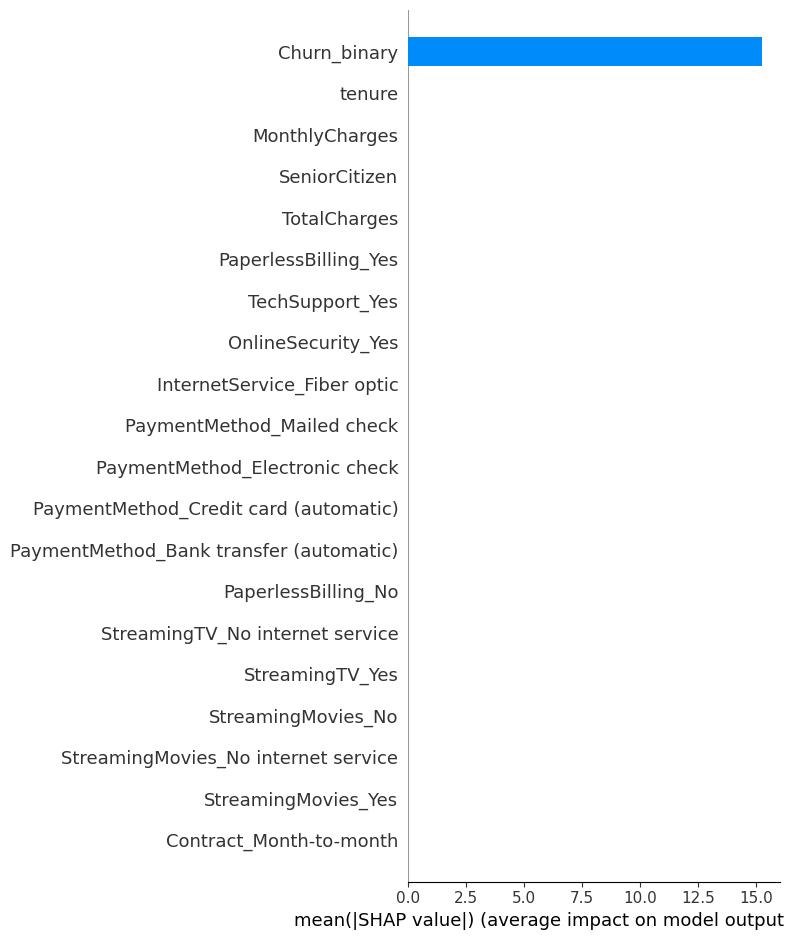

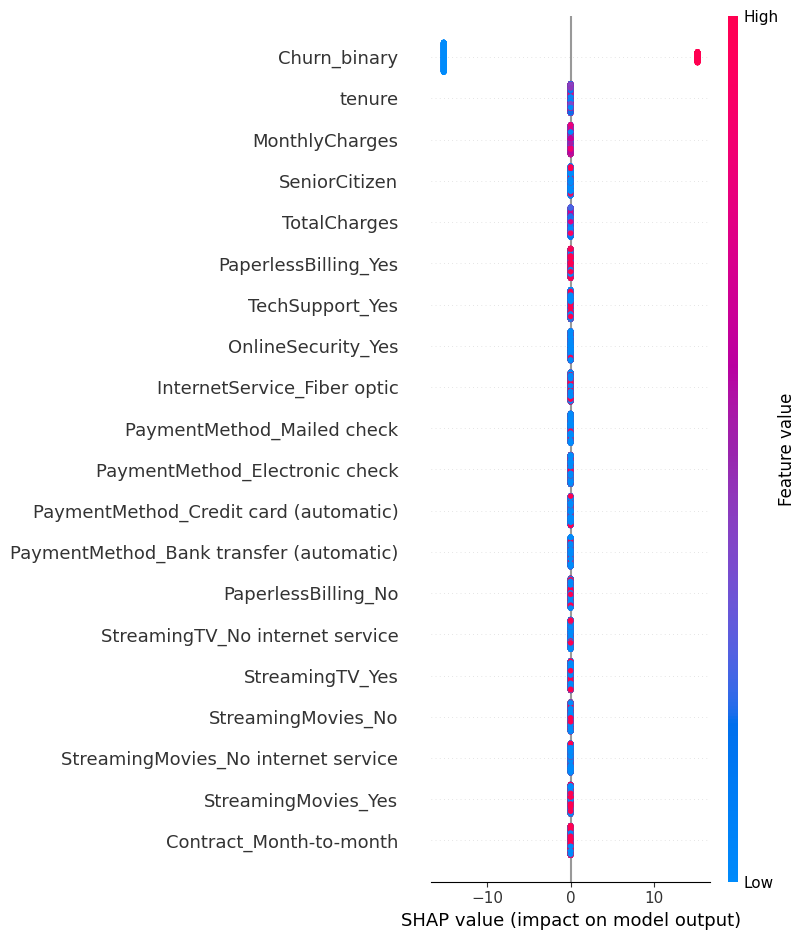

In [6]:
# Cell 2 — SHAP for customer model
cust_model = joblib.load(r"C:\Users\waghs.DESKTOP-OFO3QK6\churn-prediction-analysis\models\customer_churn_lgbm.pkl")
cust_test = pd.read_csv(r"C:\Users\waghs.DESKTOP-OFO3QK6\churn-prediction-analysis\data\processed\customer_churn_lgbm_predictions.csv")
X_cust = cust_test.drop(['actual','predicted','churn_probability'], axis=1)

explainer_c = shap.TreeExplainer(cust_model)
shap_vals_c = explainer_c.shap_values(X_cust)

# Global — top features driving customer churn
plt.figure(figsize=(10,6))
shap.summary_plot(shap_vals_c, X_cust, plot_type='bar',
                  title='Top drivers of customer churn', show=False)
plt.tight_layout()
plt.savefig('../outputs/shap_customer_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm — direction and magnitude
shap.summary_plot(shap_vals_c, X_cust,
                  title='Customer churn drivers — direction')

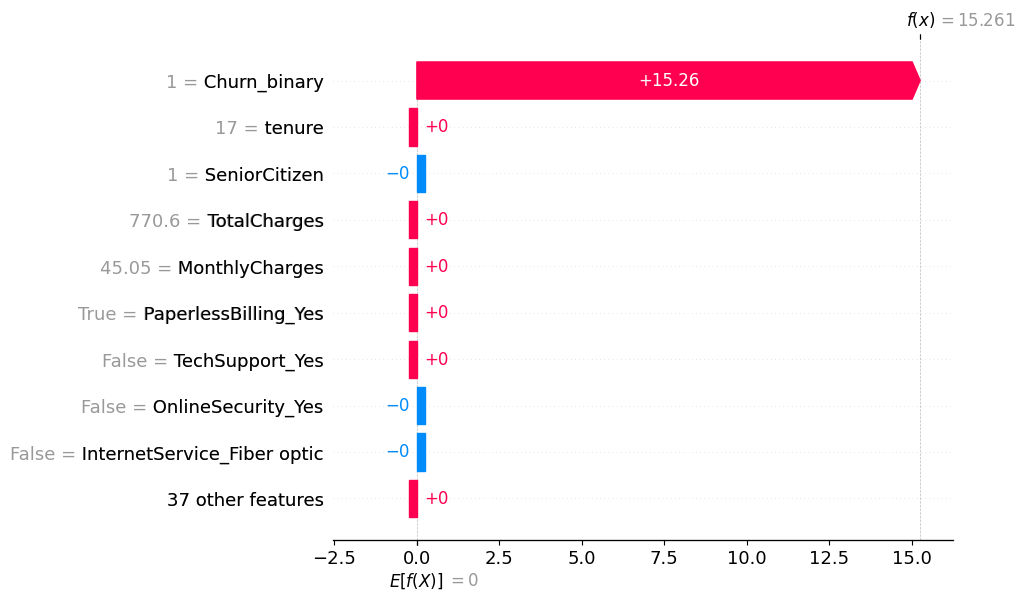

In [7]:
# Cell 3 — waterfall chart for a HIGH-RISK customer
high_risk_idx = cust_test['churn_probability'].idxmax()
shap.waterfall_plot(
    shap.Explanation(
        values=shap_vals_c[high_risk_idx],
        base_values=explainer_c.expected_value,
        data=X_cust.iloc[high_risk_idx],
        feature_names=X_cust.columns.tolist()
    )
)

c:\Users\waghs.DESKTOP-OFO3QK6\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


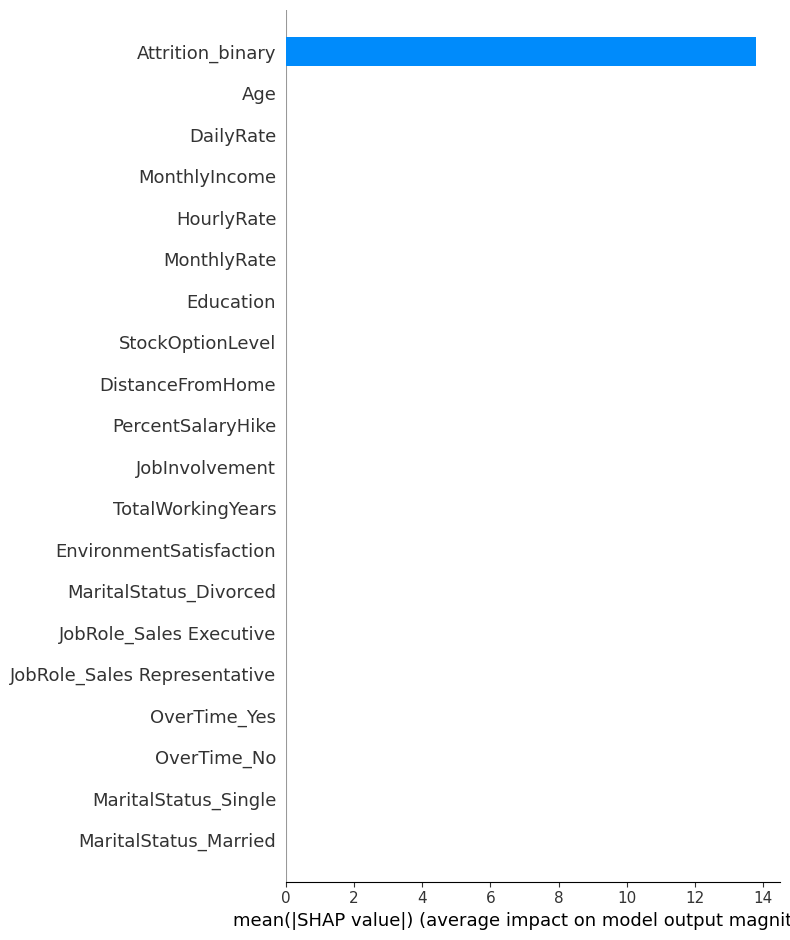

<Figure size 640x480 with 0 Axes>

In [8]:
# Cell 4 — SHAP for employee model (same structure)
emp_model = joblib.load('../models/employee_churn_lgbm.pkl')
emp_test  = pd.read_csv('../data/processed/employee_churn_lgbm_predictions.csv')
X_emp = emp_test.drop(['actual','predicted','churn_probability'], axis=1)

explainer_e = shap.TreeExplainer(emp_model)
shap_vals_e = explainer_e.shap_values(X_emp)

shap.summary_plot(shap_vals_e, X_emp, plot_type='bar',
                  title='Top drivers of employee attrition')
plt.savefig('../outputs/shap_employee_summary.png', dpi=150, bbox_inches='tight')

In [9]:
# Cell 5 — save top 5 SHAP features for each model (for Streamlit app)
import numpy as np
top_cust = pd.Series(
    np.abs(shap_vals_c).mean(axis=0),
    index=X_cust.columns
).nlargest(10)
top_emp = pd.Series(
    np.abs(shap_vals_e).mean(axis=0),
    index=X_emp.columns
).nlargest(10)

top_cust.to_csv('../data/processed/top_customer_features.csv')
top_emp.to_csv('../data/processed/top_employee_features.csv')
print("Top customer churn drivers:\n", top_cust)
print("\nTop employee attrition drivers:\n", top_emp)

Top customer churn drivers:
 Churn_binary                   1.526075e+01
tenure                         1.045630e-13
MonthlyCharges                 3.567970e-14
SeniorCitizen                  1.384838e-14
TotalCharges                   1.350209e-14
PaperlessBilling_Yes           2.338172e-15
TechSupport_Yes                4.301456e-16
OnlineSecurity_Yes             7.513236e-18
InternetService_Fiber optic    6.280216e-18
gender_Female                  0.000000e+00
dtype: float64

Top employee attrition drivers:
 Attrition_binary     1.381075e+01
Age                  9.651709e-14
DailyRate            3.288800e-14
MonthlyIncome        1.180794e-14
HourlyRate           7.310741e-15
MonthlyRate          5.487506e-15
Education            9.680052e-16
StockOptionLevel     6.490329e-16
DistanceFromHome     3.190608e-16
PercentSalaryHike    7.765248e-17
dtype: float64
